# 04 — Predicting which active players are about to stop (Part 4)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

from db import run_query, close
from style import BLUE, ORANGE, AQUA, INK_2, MUTED, GREYS, save

pd.set_option("display.width", 140)
DAY = pd.Timedelta(days=1)

In [2]:
pdays = run_query("""SELECT device_id, activity_dt AS dt, player_level AS level,
                            session_count AS sessions, playtime_minutes AS playtime FROM player_day""")
prof = run_query("""SELECT device_id, install_date, platform, country_tier AS tier,
                           acquisition_channel AS channel FROM player_profile""")
pur = run_query("SELECT device_id, event_dt AS dt, usd_amount AS usd FROM purchase_clean WHERE usd_amount > 0")
ads = run_query("""SELECT device_id, event_dt AS dt, COUNT(*) AS n FROM ad_view_local
                   WHERE status = 'completed' GROUP BY device_id, event_dt""")
spend = run_query("SELECT device_id, DATE(event_ts) AS dt, COUNT(*) AS n FROM currency_spend GROUP BY device_id, DATE(event_ts)")
exploit = set(run_query("SELECT DISTINCT device_id FROM currency_spend WHERE currency_value > 50000").device_id)
for df in (pdays, pur, ads, spend):
    df["dt"] = pd.to_datetime(df["dt"])
prof["install_date"] = pd.to_datetime(prof["install_date"])
print({k: len(v) for k, v in dict(pdays=pdays, pur=pur, ads=ads, spend=spend).items()}, "exploit accounts:", len(exploit))

{'pdays': 667435, 'pur': 15078, 'ads': 349073, 'spend': 342131} exploit accounts: 36


In [3]:
pdays = pdays.sort_values(["device_id", "dt"])
pdays["next_dt"] = pdays.groupby("device_id")["dt"].shift(-1)
gap = (pdays["next_dt"] - pdays["dt"]).dt.days
end = pd.Timestamp("2026-04-30")

print("Gaps between consecutive active days:")
for k in (3, 7, 14, 21, 28):
    print(f"  <= {k:2d} days: {(gap.dropna() <= k).mean():.1%}")

ret = []
for k in (3, 7, 10, 14, 21, 28):
    silent = (pdays["next_dt"].isna() | (gap > k)) & (pdays["dt"] + (k + 30) * DAY <= end)
    ret.append({"silent_for_k_days": k, "spells": int(silent.sum()),
                "came_back_within_30_more_days": (gap[silent] <= k + 30).mean()})
ret = pd.DataFrame(ret)
display(ret.style.format({"came_back_within_30_more_days": "{:.1%}"}))

Gaps between consecutive active days:
  <=  3 days: 49.6%
  <=  7 days: 73.9%
  <= 14 days: 89.3%
  <= 21 days: 94.9%
  <= 28 days: 97.4%


,silent_for_k_days,spells,came_back_within_30_more_days
0,3,200652,92.7%
1,7,107577,90.1%
2,10,72523,88.2%
3,14,45757,85.9%
4,21,22498,82.1%
5,28,11941,78.7%


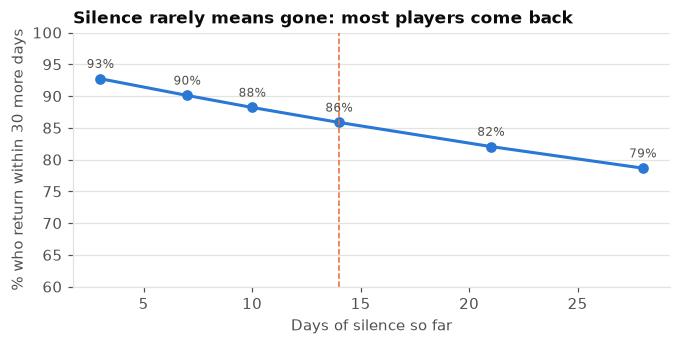

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(ret.silent_for_k_days, ret.came_back_within_30_more_days * 100, marker="o", color=BLUE)
for _, r in ret.iterrows():
    ax.annotate(f"{r.came_back_within_30_more_days:.0%}", (r.silent_for_k_days, r.came_back_within_30_more_days * 100),
                textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8, color=INK_2)
ax.axvline(14, color=ORANGE, lw=1, ls="--")
ax.set_ylim(60, 100)
ax.set_xlabel("Days of silence so far")
ax.set_ylabel("% who return within 30 more days")
ax.set_title("Silence rarely means gone: most players come back")
save(fig, "p4_return_curve")
plt.show()

In [5]:
def window(df, t, start, stop):
    return df[(df.dt >= t - start * DAY) & (df.dt <= t - stop * DAY)]


def build_snapshot(t):
    last7 = window(pdays, t, 6, 0)
    ids = pd.Index(last7.device_id.unique()).difference(list(exploit))
    f = pd.DataFrame(index=ids)
    f.index.name = "device_id"
    future = pdays[(pdays.dt > t) & (pdays.dt <= t + 14 * DAY)]
    f["lapse14"] = (~f.index.isin(future.device_id.unique())).astype(int)

    hist = pdays[(pdays.dt <= t) & pdays.device_id.isin(ids)].sort_values("dt")
    last7 = last7[last7.device_id.isin(ids)]
    f["days_since_active"] = (t - hist.groupby("device_id").dt.max()).dt.days
    f["active_days_7"] = last7.groupby("device_id").size()
    f["sessions_7"] = last7.groupby("device_id").sessions.sum()
    f["sessions_per_active_day"] = f.sessions_7 / f.active_days_7
    level_now = hist.groupby("device_id")["level"].last()
    level_then = (hist[hist.dt <= t - 14 * DAY].groupby("device_id")["level"].last()
                  .reindex(ids).fillna(hist.groupby("device_id")["level"].first()))
    f["level"] = level_now
    f["level_gain_14"] = level_now - level_then

    p = pur[(pur.dt <= t) & pur.device_id.isin(ids)]
    f["revenue_28"] = window(p, t, 27, 0).groupby("device_id").usd.sum()
    f["is_payer"] = f.index.isin(p.device_id.unique()).astype(int)
    f["ads_completed_7"] = window(ads, t, 6, 0).groupby("device_id").n.sum()
    f["spend_events_7"] = window(spend, t, 6, 0).groupby("device_id").n.sum()

    f = f.reset_index().merge(prof, on="device_id", how="left")
    f["tenure_days"] = (t - f.install_date).dt.days
    f["levels_per_week"] = f.level / np.maximum(f.tenure_days, 1) * 7
    f["snapshot"] = t
    return f


snapshots = pd.date_range("2026-01-29", "2026-04-16", freq="7D")
data = pd.concat([build_snapshot(t) for t in snapshots], ignore_index=True)
for c in ("revenue_28", "ads_completed_7", "spend_events_7"):
    data[c] = data[c].fillna(0)
assert data[["device_id", "snapshot"]].duplicated().sum() == 0
display(data.groupby("snapshot").agg(active_players=("device_id", "size"), lapse_rate=("lapse14", "mean")).round(3))

,active_players,lapse_rate
snapshot,,
2026-01-29,13831,0.197
2026-02-05,15265,0.199
2026-02-12,16507,0.201
2026-02-19,17666,0.204
2026-02-26,18963,0.202
2026-03-05,20709,0.205
2026-03-12,22901,0.200
2026-03-19,25275,0.199
2026-03-26,28111,0.196


In [6]:
train = data[data.snapshot <= "2026-03-05"]
val = data[data.snapshot.isin(pd.to_datetime(["2026-03-12", "2026-03-19"]))]
test = data[data.snapshot >= "2026-04-02"]
print({n: (len(d), round(d.lapse14.mean(), 3)) for n, d in dict(train=train, val=val, test=test).items()})

CATS = ["platform", "tier", "channel"]
LOG = FunctionTransformer(np.log1p, feature_names_out="one-to-one")


def make_model(log_cols, lin_cols):
    pre = ColumnTransformer([
        ("log", Pipeline([("log1p", LOG), ("scale", StandardScaler())]), log_cols),
        ("lin", StandardScaler(), lin_cols),
        ("cat", OneHotEncoder(drop="first"), CATS),
    ])
    return Pipeline([("pre", pre), ("lr", LogisticRegression(max_iter=2000))])


candidates = {
    "baseline: recency + frequency only": ([], ["days_since_active", "active_days_7"]),
    "all features (collinear)": (["sessions_7", "revenue_28", "ads_completed_7", "spend_events_7", "tenure_days"],
                                 ["days_since_active", "active_days_7", "level", "level_gain_14", "is_payer"]),
    "interpretable (chosen)": (["revenue_28", "ads_completed_7", "spend_events_7", "tenure_days"],
                               ["days_since_active", "active_days_7", "sessions_per_active_day",
                                "level_gain_14", "levels_per_week", "is_payer"]),
}
rows = []
for name, (lg, ln) in candidates.items():
    if name.startswith("baseline"):
        m = Pipeline([("pre", ColumnTransformer([("lin", StandardScaler(), ln)])),
                      ("lr", LogisticRegression(max_iter=2000))])
    else:
        m = make_model(lg, ln)
    m.fit(train, train.lapse14)
    p = m.predict_proba(val)[:, 1]
    rows.append({"model": name, "val_roc_auc": roc_auc_score(val.lapse14, p),
                 "val_pr_auc": average_precision_score(val.lapse14, p)})
display(pd.DataFrame(rows).round(4))

{'train': (102941, np.float64(0.202)), 'val': (48176, np.float64(0.199)), 'test': (104675, np.float64(0.19))}


,model,val_roc_auc,val_pr_auc
0,baseline: recency + frequency only,0.6093,0.2493
1,all features (collinear),0.7568,0.4359
2,interpretable (chosen),0.7463,0.4050


In [7]:
print(data[["tenure_days", "level", "levels_per_week", "level_gain_14", "active_days_7",
            "sessions_per_active_day"]].corr().round(2))

                         tenure_days  level  levels_per_week  level_gain_14  active_days_7  sessions_per_active_day
tenure_days                     1.00   0.88            -0.45          -0.37          -0.28                     0.04
level                           0.88   1.00            -0.46          -0.20          -0.15                     0.16
levels_per_week                -0.45  -0.46             1.00           0.04           0.27                     0.02
level_gain_14                  -0.37  -0.20             0.04           1.00           0.61                     0.09
active_days_7                  -0.28  -0.15             0.27           0.61           1.00                     0.10
sessions_per_active_day         0.04   0.16             0.02           0.09           0.10                     1.00


In [8]:
log_cols, lin_cols = candidates["interpretable (chosen)"]
trval = pd.concat([train, val])
model = make_model(log_cols, lin_cols).fit(trval, trval.lapse14)
full = make_model(*candidates["all features (collinear)"]).fit(trval, trval.lapse14)
base = Pipeline([("pre", ColumnTransformer([("lin", StandardScaler(), ["days_since_active", "active_days_7"])])),
                 ("lr", LogisticRegression(max_iter=2000))]).fit(trval, trval.lapse14)

y = test.lapse14.to_numpy()
p = model.predict_proba(test)[:, 1]
summary = pd.DataFrame([
    {"model": n, "test_roc_auc": roc_auc_score(y, q), "test_pr_auc": average_precision_score(y, q),
     "brier": brier_score_loss(y, q)}
    for n, q in [("interpretable (chosen)", p), ("all features", full.predict_proba(test)[:, 1]),
                 ("baseline", base.predict_proba(test)[:, 1])]
])
print(f"test rows {len(y):,}, lapse rate {y.mean():.3f}")
display(summary.round(4))

order = np.argsort(-p)
topk = []
for k in (0.05, 0.10, 0.20, 0.30, 0.50):
    sel = order[: int(len(y) * k)]
    topk.append({"target_top": f"{k:.0%}", "threshold_p": p[sel].min(), "precision": y[sel].mean(),
                 "recall": y[sel].sum() / y.sum(), "lift": y[sel].mean() / y.mean(),
                 "wasted_offers_per_100": 100 * (1 - y[sel].mean())})
topk = pd.DataFrame(topk)
display(topk.round(3))

test rows 104,675, lapse rate 0.190


,model,test_roc_auc,test_pr_auc,brier
0,interpretable (chosen),0.7442,0.3901,0.1355
1,all features,0.7514,0.4112,0.1338
2,baseline,0.6101,0.2391,0.1501


,target_top,threshold_p,precision,recall,lift,wasted_offers_per_100
0,5%,0.442,0.520,0.137,2.738,48.041
1,10%,0.381,0.469,0.247,2.474,53.062
2,20%,0.303,0.403,0.425,2.126,59.666
3,30%,0.248,0.361,0.570,1.902,63.919
4,50%,0.165,0.298,0.786,1.571,70.184


In [9]:
coef = pd.Series(model.named_steps["lr"].coef_[0],
                 index=model.named_steps["pre"].get_feature_names_out()).sort_values()
display(coef.round(3).to_frame("coefficient (per SD / vs reference)"))

,coefficient (per SD / vs reference)
lin__levels_per_week,-0.537
lin__sessions_per_active_day,-0.256
log__ads_completed_7,-0.194
lin__level_gain_14,-0.169
log__spend_events_7,-0.132
lin__is_payer,-0.062
cat__platform_iOS,-0.014
lin__days_since_active,-0.009
log__revenue_28,0.003
cat__tier_2,0.036


In [10]:
display(data.groupby(pd.cut(data.tenure_days, [-1, 7, 14, 30, 60, 120, 400],
                            labels=["0-7", "8-14", "15-30", "31-60", "61-120", "121+"]), observed=True)
        .lapse14.agg(lapse_rate="mean", rows="size").round(3))

,lapse_rate,rows
tenure_days,,
0-7,0.045,43870
8-14,0.092,33289
15-30,0.135,54712
31-60,0.199,57364
61-120,0.276,44027
121+,0.391,50641


,mean_predicted,observed,players
decile,,,
1,0.017,0.024,10468
2,0.050,0.048,10467
3,0.081,0.081,10468
4,0.113,0.108,10467
5,0.147,0.146,10468
6,0.184,0.180,10467
7,0.225,0.229,10467
8,0.274,0.276,10468
9,0.339,0.337,10467


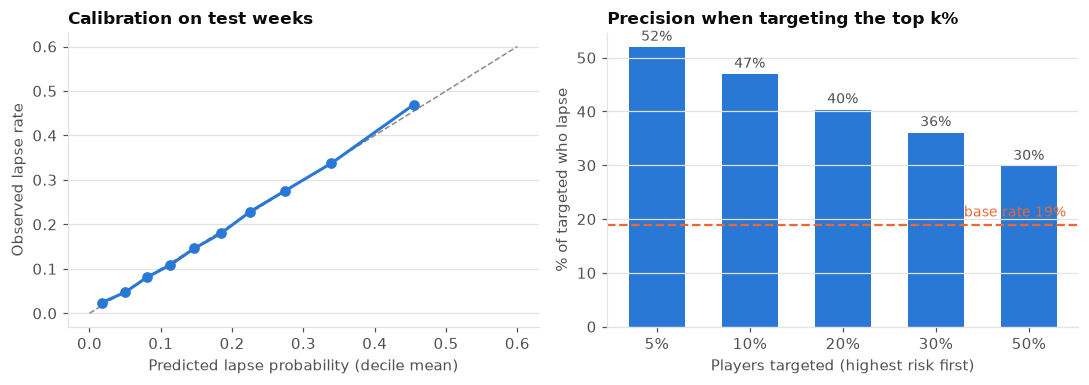

In [11]:
test = test.assign(p=p)
test["decile"] = pd.qcut(test.p, 10, labels=False) + 1
calib = test.groupby("decile").agg(mean_predicted=("p", "mean"), observed=("lapse14", "mean"), players=("p", "size"))
display(calib.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
ax = axes[0]
ax.plot([0, 0.6], [0, 0.6], color=MUTED, lw=1, ls="--")
ax.plot(calib.mean_predicted, calib.observed, marker="o", color=BLUE)
ax.set_xlabel("Predicted lapse probability (decile mean)")
ax.set_ylabel("Observed lapse rate")
ax.set_title("Calibration on test weeks")
ax = axes[1]
ax.bar(topk.target_top, topk.precision * 100, color=BLUE, width=0.6)
ax.axhline(y.mean() * 100, color=ORANGE, lw=1.5, ls="--")
ax.text(4.4, y.mean() * 100 + 1.5, f"base rate {y.mean():.0%}", ha="right", color=ORANGE, fontsize=9)
for i, r in topk.iterrows():
    ax.text(i, r.precision * 100 + 1.2, f"{r.precision:.0%}", ha="center", fontsize=9, color=INK_2)
ax.set_xlabel("Players targeted (highest risk first)")
ax.set_ylabel("% of targeted who lapse")
ax.set_title("Precision when targeting the top k%")
fig.tight_layout()
save(fig, "p4_model")
plt.show()

In [12]:
def seg_table(col, labels=None):
    g = test.groupby(col if labels is None else labels)
    return g.apply(lambda d: pd.Series({
        "rows": len(d), "lapse_rate": d.lapse14.mean(),
        "roc_auc": roc_auc_score(d.lapse14, d.p) if d.lapse14.nunique() == 2 else np.nan,
        "share_in_top10pct": (d.p >= topk.loc[1, "threshold_p"]).mean()}), include_groups=False)


tenure_band = pd.cut(test.tenure_days, [-1, 13, 60, 1000], labels=["new (<14d)", "14-60d", "60d+"])
display(seg_table(None, tenure_band).round(3))
display(seg_table("tier").round(3))
display(seg_table("is_payer").round(3))
display(seg_table("platform").round(3))

,rows,lapse_rate,roc_auc,share_in_top10pct
tenure_days,,,,
new (<14d),28596.0,0.062,0.699,0.000
14-60d,41846.0,0.164,0.659,0.006
60d+,34233.0,0.328,0.651,0.299


,rows,lapse_rate,roc_auc,share_in_top10pct
tier,,,,
1,25087.0,0.228,0.723,0.136
2,19094.0,0.229,0.720,0.149
3,19786.0,0.205,0.740,0.119
4,40708.0,0.140,0.748,0.046


,rows,lapse_rate,roc_auc,share_in_top10pct
is_payer,,,,
0,90286.0,0.189,0.752,0.106
1,14389.0,0.196,0.693,0.064


,rows,lapse_rate,roc_auc,share_in_top10pct
platform,,,,
Android,73940.0,0.181,0.747,0.093
iOS,30735.0,0.211,0.735,0.116


In [13]:
hist = data[data.snapshot <= "2026-03-26"].copy()   # 30 days of follow-up available
fwd = []
for t, g in hist.groupby("snapshot"):
    r = pur[(pur.dt > t) & (pur.dt <= t + 30 * DAY)].groupby("device_id").usd.sum()
    fwd.append(g.assign(rev_next30=g.device_id.map(r).fillna(0)))
hist = pd.concat(fwd)
hist["p"] = model.predict_proba(hist)[:, 1]
hist["risk_band"] = pd.qcut(hist.p, 5, labels=["lowest", "low", "mid", "high", "highest"])
value = hist.groupby(["risk_band", "lapse14"], observed=True).rev_next30.mean().unstack()
value.columns = ["stayed", "lapsed"]
value["revenue_lost_per_lapse"] = value.stayed - value.lapsed
display(value.round(3))

# return after lapse (needs 14 + 30 days of follow-up)
back = []
for t, g in data[(data.snapshot <= "2026-03-12") & (data.lapse14 == 1)].groupby("snapshot"):
    later = pdays[(pdays.dt > t + 14 * DAY) & (pdays.dt <= t + 44 * DAY)].device_id.unique()
    back.append(g.device_id.isin(later).mean())
print(f"lapsers who return within 30 days after the lapse window: {np.mean(back):.1%}")

V = value.loc["highest", "revenue_lost_per_lapse"]
print(f"V (highest risk band): ${V:.2f} of IAP revenue per prevented lapse over 30 days (an upper bound)")

,stayed,lapsed,revenue_lost_per_lapse
risk_band,,,
lowest,2.198,0.622,1.576
low,1.679,0.777,0.902
mid,1.502,0.583,0.919
high,1.203,0.500,0.703
highest,0.915,0.292,0.623


lapsers who return within 30 days after the lapse window: 84.5%
V (highest risk band): $0.62 of IAP revenue per prevented lapse over 30 days (an upper bound)


In [14]:
# Break-even offer cost: the most an offer can cost per targeted player and still
# pay back, for a given targeting depth and save rate u.  c_max = mean(p) * u * V
be = []
for k in (0.05, 0.10, 0.20):
    sel = order[: int(len(y) * k)]
    for u in (0.10, 0.20, 0.30):
        be.append({"target_top": f"{k:.0%}", "save_rate_u": u, "mean_p_targeted": p[sel].mean(),
                   "precision": y[sel].mean(), "max_offer_cost_usd": p[sel].mean() * u * V})
be = pd.DataFrame(be)
display(be.pivot(index="target_top", columns="save_rate_u", values="max_offer_cost_usd").round(3))

save_rate_u,0.1,0.2,0.3
target_top,,,
10%,0.028,0.057,0.085
20%,0.025,0.049,0.074
5%,0.031,0.062,0.094


## Final Interpretation

The model predicts **14-day inactivity risk** rather than permanent churn. The definition is supported by the observed gap structure: about **89% of activity gaps are within 14 days**, but even after a 28-day silence, **79% return within the following month**.

On unseen April weeks, the interpretable logistic model achieves **ROC-AUC 0.744 and PR-AUC 0.390** against a **19% lapse base rate**. Targeting the highest-risk 10% gives **46.9% precision and 2.47× lift**, with probabilities reasonably calibrated across deciles.

The model is driven mainly by engagement depth and progression. Performance is weaker within individual tenure bands, and payer AUC is lower than non-payer AUC, so a single model should not be assumed equally effective for every lifecycle group.

The economics are the key constraint. In the highest-risk group, the observed 30-day IAP gap between stayers and lapsers is only about **$0.62 per player**, and **84.5% of lapsers return within 30 days**. This makes the $0.62 an upper-bound value, not causal incremental revenue.

**Action:** Use the model for narrow risk-based targeting rather than assuming that identifying a lapser creates value. The correct next step is a **randomised holdout test** within the high-risk group to estimate the true save rate and measure cannibalisation. The offer threshold should then be set from `p × u × V > c`; without an observed treatment effect, targeting alone cannot establish ROI.

In [15]:
close()